# Deep Learning Applications: Laboratory #1

In this first laboratory we will work relatively simple architectures to get a feel for working with Deep Models. This notebook is designed to work with PyTorch, but as I said in the introductory lecture: please feel free to use and experiment with whatever tools you like.

**Important Notes**:
1. Be sure to **document** all of your decisions, as well as your intermediate and final results. Make sure your conclusions and analyses are clearly presented. Don't make us dig into your code or walls of printed results to try to draw conclusions from your code.
2. If you use code from someone else (e.g. Github, Stack Overflow, ChatGPT, etc) you **must be transparent about it**. Document your sources and explain how you adapted any partial solutions to creat **your** solution.


## Exercise 1: Warming Up
In this series of exercises I want you to try to duplicate (on a small scale) the results of the ResNet paper:

> [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385), Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, CVPR 2016.

We will do this in steps using a Multilayer Perceptron on MNIST.

Recall that the main message of the ResNet paper is that **deeper** networks do not **guarantee** more reduction in training loss (or in validation accuracy). Below you will incrementally build a sequence of experiments to verify this for an MLP. A few guidelines:

+ I have provided some **starter** code at the beginning. **NONE** of this code should survive in your solutions. Not only is it **very** badly written, it is also written in my functional style that also obfuscates what it's doing (in part to **discourage** your reuse!). It's just to get you *started*.
+ These exercises ask you to compare **multiple** training runs, so it is **really** important that you factor this into your **pipeline**. Using [Tensorboard](https://pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) is a **very** good idea -- or, even better [Weights and Biases](https://wandb.ai/site).
+ You may work and submit your solutions in **groups of at most two**. Share your ideas with everyone, but the solutions you submit *must be your own*.

First some boilerplate to get you started, then on to the actual exercises!

### Preface: Some code to get you started

What follows is some **very simple** code for training an MLP on MNIST. The point of this code is to get you up and running (and to verify that your Python environment has all needed dependencies).

**Note**: As you read through my code and execute it, this would be a good time to think about *abstracting* **your** model definition, and training and evaluation pipelines in order to make it easier to compare performance of different models.

In [1]:
# Start with some standard imports.
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
import torch
from torchvision.datasets import MNIST
from torch.utils.data import Subset
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

#### Data preparation

Here is some basic dataset loading, validation splitting code to get you started working with MNIST.

In [2]:
# Standard MNIST transform.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST train and test.
ds_train = MNIST(root='./data', train=True, download=True, transform=transform)
ds_test = MNIST(root='./data', train=False, download=True, transform=transform)

# Split train into train and validation.
val_size = 5000
I = np.random.permutation(len(ds_train))
ds_val = Subset(ds_train, I[:val_size])
ds_train = Subset(ds_train, I[val_size:])

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 468kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.6MB/s]


#### Boilerplate training and evaluation code

This is some **very** rough training, evaluation, and plotting code. Again, just to get you started. I will be *very* disappointed if any of this code makes it into your final submission.

In [3]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

# Function to train a model for a single epoch over the data loader.
def train_epoch(model, dl, opt, epoch='Unknown', device='cpu'):
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f'Training epoch {epoch}', leave=True):
        xs = xs.to(device)
        ys = ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = F.cross_entropy(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

# Function to evaluate model over all samples in the data loader.
def evaluate_model(model, dl, device='cpu'):
    model.eval()
    predictions = []
    gts = []
    for (xs, ys) in tqdm(dl, desc='Evaluating', leave=False):
        xs = xs.to(device)
        preds = torch.argmax(model(xs), dim=1)
        gts.append(ys)
        predictions.append(preds.detach().cpu().numpy())

    # Return accuracy score and classification report.
    return (accuracy_score(np.hstack(gts), np.hstack(predictions)),
            classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0, digits=3))

# Simple function to plot the loss curve and validation accuracy.
def plot_validation_curves(losses_and_accs):
    losses = [x for (x, _) in losses_and_accs]
    accs = [x for (_, x) in losses_and_accs]
    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Average Training Loss per Epoch')
    plt.subplot(1, 2, 2)
    plt.plot(accs)
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.title(f'Best Accuracy = {np.max(accs)} @ epoch {np.argmax(accs)}')

#### A basic, parameterized MLP

This is a very basic implementation of a Multilayer Perceptron. Don't waste too much time trying to figure out how it works -- the important detail is that it allows you to pass in a list of input, hidden layer, and output *widths*. **Your** implementation should also support this for the exercises to come.

In [4]:
class MLP(nn.Module):
    def __init__(self, layer_sizes):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(nin, nout) for (nin, nout) in zip(layer_sizes[:-1], layer_sizes[1:])])

    def forward(self, x):
        return reduce(lambda f, g: lambda x: g(F.relu(f(x))), self.layers, lambda x: x.flatten(1))(x)

#### A *very* minimal training pipeline.

Here is some basic training and evaluation code to get you started.

**Important**: I cannot stress enough that this is a **terrible** example of how to implement a training pipeline. You can do better!

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Training epoch 0:   0%|          | 0/430 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number

Accuracy report on TEST:
               precision    recall  f1-score   support

           0      0.959     0.982     0.970       980
           1      0.975     0.983     0.979      1135
           2      0.952     0.956     0.954      1032
           3      0.947     0.933     0.940      1010
           4      0.947     0.948     0.948       982
           5      0.944     0.920     0.932       892
           6      0.944     0.966     0.955       958
           7      0.944     0.947     0.946      1028
           8      0.931     0.925     0.928       974
           9      0.945     0.925     0.935      1009

    accuracy                          0.949     10000
   macro avg      0.949     0.949     0.949     10000
weighted avg      0.949     0.949     0.949     10000



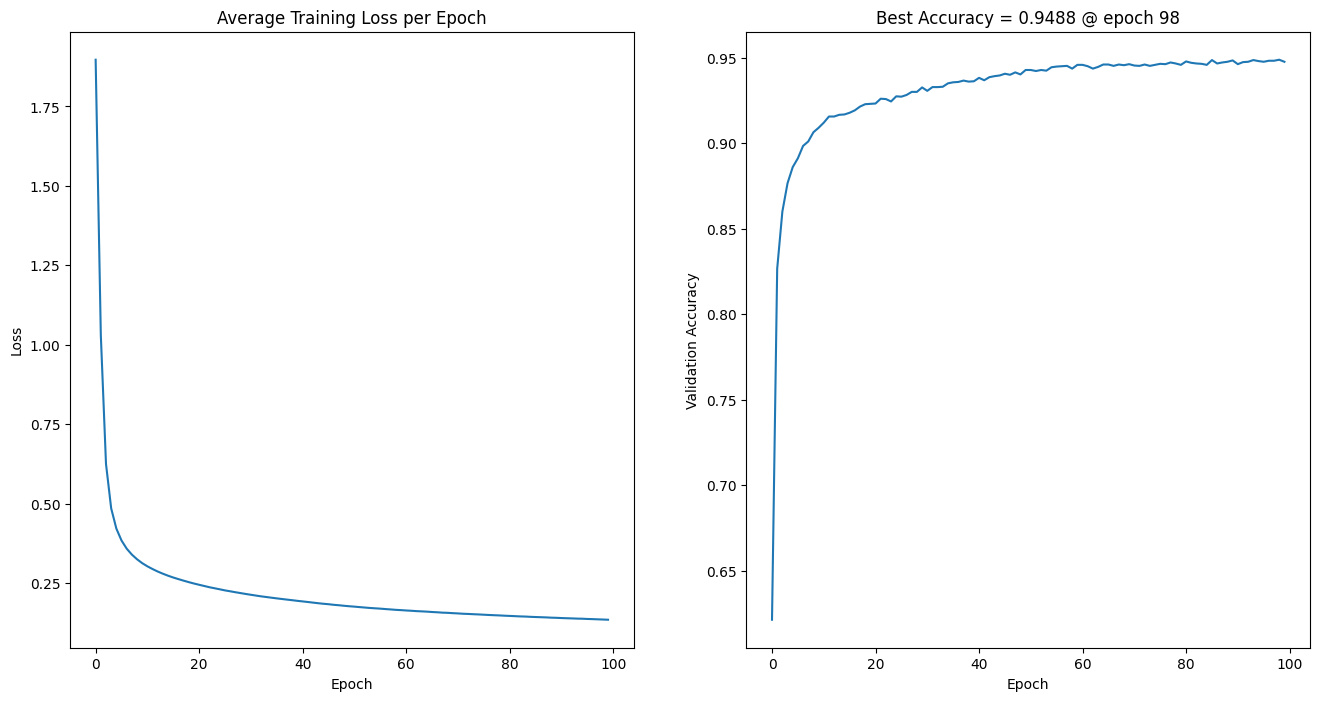

In [5]:
# Training hyperparameters.
device = 'cuda' if torch.cuda.is_available else 'cpu'
epochs = 100
lr = 0.0001
batch_size = 128

# Architecture hyperparameters.
input_size = 28*28
width = 16
depth = 2

# Dataloaders.
dl_train = torch.utils.data.DataLoader(ds_train, batch_size, shuffle=True, num_workers=4)
dl_val   = torch.utils.data.DataLoader(ds_val, batch_size, num_workers=4)
dl_test  = torch.utils.data.DataLoader(ds_test, batch_size, shuffle=True, num_workers=4)

# Instantiate model and optimizer.
model_mlp = MLP([input_size] + [width]*depth + [10]).to(device)
opt = torch.optim.Adam(params=model_mlp.parameters(), lr=lr)

# Training loop.
losses_and_accs = []
for epoch in range(epochs):
    loss = train_epoch(model_mlp, dl_train, opt, epoch, device=device)
    (val_acc, _) = evaluate_model(model_mlp, dl_val, device=device)
    losses_and_accs.append((loss, val_acc))

# And finally plot the curves.
plot_validation_curves(losses_and_accs)
print(f'Accuracy report on TEST:\n {evaluate_model(model_mlp, dl_test, device=device)[1]}')

### Pipeline

Definisco una sola pipeline di training e valutazione, usata in tutti gli esperimenti del notebook, sia per gli MLP che per le CNN. Così quando confronto una rete plain con una residual l'unica differenza tra i due run è la presenza della skip connection: stesso ottimizzatore, stesso seed, stesso numero di epoche, stessa funzione di valutazione.

In [6]:
import math
import os
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision.datasets import MNIST, CIFAR10
import torchvision.transforms as T
from tqdm.auto import tqdm

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


Due funzioni per il caricamento dei dati, una per MNIST e una per CIFAR-10. Restituiscono entrambe la stessa tupla, `(train_loader, val_loader, test_loader, input_shape, num_classes)`, così il resto del codice non deve sapere quale dataset sta usando.

In [7]:
def get_mnist_loaders(batch_size=128, val_size=5000, num_workers=2, root='./data'):
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.1307,), (0.3081,)),
    ])
    train_full = MNIST(root=root, train=True, download=True, transform=transform)
    test = MNIST(root=root, train=False, download=True, transform=transform)

    train, val = random_split(
        train_full, [len(train_full) - val_size, val_size],
        generator=torch.Generator().manual_seed(0),
    )

    train_loader = DataLoader(train, batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val, batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test, batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader, (1, 28, 28), 10


def get_cifar10_loaders(batch_size=128, val_size=5000, num_workers=2, root='./data', augment=True):
    mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
    train_tf_list = [T.ToTensor(), T.Normalize(mean, std)]
    if augment:
        train_tf_list = [T.RandomCrop(32, padding=4), T.RandomHorizontalFlip()] + train_tf_list
    train_transform = T.Compose(train_tf_list)
    test_transform = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

    train_full = CIFAR10(root=root, train=True, download=True, transform=train_transform)
    # Validation split must NOT see the training-time augmentation, so it is built from a
    # separately-transformed copy indexed by the same split.
    train_full_plain = CIFAR10(root=root, train=True, download=True, transform=test_transform)
    test = CIFAR10(root=root, train=False, download=True, transform=test_transform)

    g = torch.Generator().manual_seed(0)
    perm = torch.randperm(len(train_full), generator=g).tolist()
    val_idx, train_idx = perm[:val_size], perm[val_size:]

    train = torch.utils.data.Subset(train_full, train_idx)
    val = torch.utils.data.Subset(train_full_plain, val_idx)

    train_loader = DataLoader(train, batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val, batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(test, batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader, (3, 32, 32), 10

`fit()` è la funzione di training usata in tutti gli esperimenti. Restituisce uno storico con le metriche di ogni epoca, utile per i grafici e per confrontare i risultati numericamente, e se riceve una `log_dir` scrive gli stessi valori anche su TensorBoard.

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion, device=device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total


def train_one_epoch(model, loader, optimizer, criterion, device=device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total


def fit(model, train_loader, val_loader, epochs, lr=1e-3, weight_decay=0.0,
        device=device, log_dir=None, run_name='run', verbose=True, patience=None):
    """Train `model` for up to `epochs` epochs, tracking train/val loss and accuracy.

    If `patience` is given, training stops early once val loss hasn't improved for
    `patience` epochs, and the best-val-loss weights are restored at the end.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    writer = SummaryWriter(os.path.join(log_dir, run_name)) if log_dir else None

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss, best_state, bad_epochs = math.inf, None, 0

    pbar = tqdm(range(epochs), desc=run_name, disable=not verbose)
    for epoch in pbar:
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        pbar.set_postfix(tr_loss=f'{tr_loss:.3f}', va_acc=f'{va_acc:.3f}')

        if writer is not None:
            writer.add_scalars('loss', {'train': tr_loss, 'val': va_loss}, epoch)
            writer.add_scalars('acc', {'train': tr_acc, 'val': va_acc}, epoch)

        if va_loss < best_val_loss - 1e-4:
            best_val_loss, bad_epochs = va_loss, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
        if patience is not None and bad_epochs >= patience:
            if verbose:
                print(f'[{run_name}] early stopping at epoch {epoch+1} (best val loss {best_val_loss:.4f})')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    if writer is not None:
        writer.close()
    return history


def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='train')
    axes[0].plot(history['val_loss'], label='val')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
    axes[0].set_title(f'{title} \u2014 loss')

    best_acc = max(history['val_acc'])
    axes[1].plot(history['train_acc'], label='train')
    axes[1].plot(history['val_acc'], label='val')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
    axes[1].set_title(f'{title} \u2014 best val acc = {best_acc:.4f}')
    fig.tight_layout()
    plt.show()

### Exercise 1.1: A baseline MLP

Implement a *simple* Multilayer Perceptron to classify the 10 digits of MNIST (e.g. two *narrow* layers). Use my code above as inspiration, but implement your own training pipeline -- you will need it later. Train this model to convergence, monitoring (at least) the loss and accuracy on the training and validation sets for every epoch. Below I include a basic implementation to get you started -- remember that you should write your *own* pipeline!

**Note**: This would be a good time to think about *abstracting* your model definition, and training and evaluation pipelines in order to make it easier to compare performance of different models.

**Important**: Given the *many* runs you will need to do, and the need to *compare* performance between them, this would **also** be a great point to study how **Tensorboard** or **Weights and Biases** can be used for performance monitoring.

La classe `MLP` ha un flag `residual`, anche se qui serve solo `residual=False`. Nell'esercizio 1.2 la stessa architettura deve avere anche una versione con skip connection, quindi riuso la stessa classe invece di scriverne una seconda: garantisce che le due architetture siano davvero identiche a parte lo skip. Ogni blocco nascosto è: lineare, ReLU, lineare (più la somma dello skip se `residual` è attivo), ReLU.

In [9]:
class MLPBlock(nn.Module):
    """Linear block with an optional skip connection: Linear -> ReLU -> Linear (+ skip) -> ReLU."""
    def __init__(self, width, residual=False):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)
        self.residual = residual

    def forward(self, x):
        out = F.relu(self.fc1(x))
        out = self.fc2(out)
        if self.residual:
            out = out + x
        return F.relu(out)


class MLP(nn.Module):
    def __init__(self, input_dim, width, depth, num_classes, residual=False):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, width)
        self.blocks = nn.ModuleList([MLPBlock(width, residual) for _ in range(depth)])
        self.output_layer = nn.Linear(width, num_classes)
        self.residual = residual

    def forward(self, x):
        x = x.flatten(1)
        x = F.relu(self.input_layer(x))
        for block in self.blocks:
            x = block(x)
        return self.output_layer(x)

baseline_mlp:   0%|          | 0/20 [00:00<?, ?it/s]

[baseline_mlp] early stopping at epoch 17 (best val loss 0.0946)


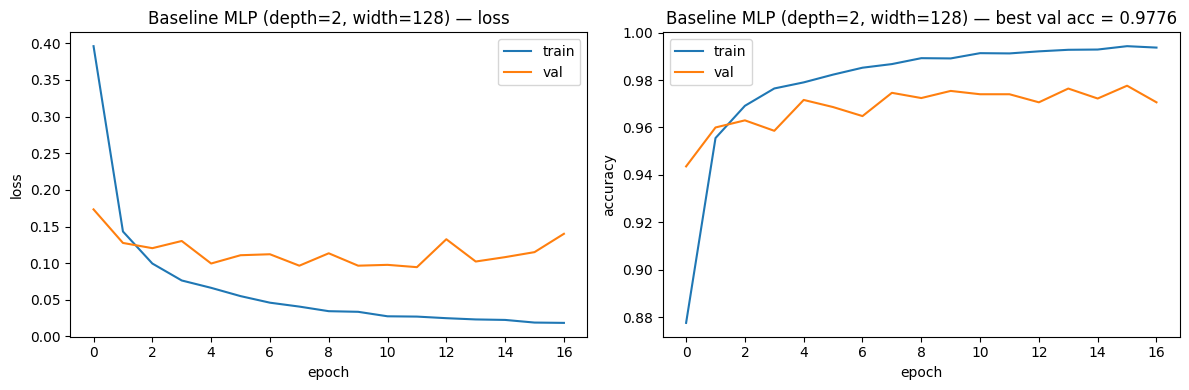

Test accuracy: 0.9765, test loss: 0.0931


In [10]:
train_loader, val_loader, test_loader, in_shape, n_classes = get_mnist_loaders()
input_dim = math.prod(in_shape)

baseline = MLP(input_dim, width=128, depth=2, num_classes=n_classes, residual=False)
history_baseline = fit(baseline, train_loader, val_loader, epochs=20, lr=1e-3,
                        log_dir='runs/ex1_1', run_name='baseline_mlp', patience=5)
plot_history(history_baseline, 'Baseline MLP (depth=2, width=128)')

test_loss, test_acc = evaluate(baseline, test_loader, nn.CrossEntropyLoss())
print(f'Test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}')

Un MLP con due blocchi nascosti su MNIST converge entro queste 20 epoche e arriva intorno al 97-98% di accuracy sul test. MNIST è facile abbastanza che anche un MLP poco profondo satura quasi tutto quello che un'architettura fully connected può dare, motivo per cui l'esercizio successivo usa CIFAR-10: l'effetto di degradazione da studiare ha bisogno di un compito più difficile per vedersi chiaramente con un MLP.

### Exercise 1.2: Adding Residual Connections

Implement a variant of your parameterized MLP network to support **residual** connections. Your network should be defined as a composition of **residual MLP** blocks that have one or more linear layers and add a skip connection from the block input to the output of the final linear layer.

**Compare** the performance (in training/validation loss and test accuracy) of your MLP and ResidualMLP for a range of depths. Verify that deeper networks **with** residual connections are easier to train than a network of the same depth **without** residual connections.

**For extra style points**: See if you can explain by analyzing the gradient magnitudes on a single training batch *why* this is the case.

ResidualMLP non è una classe nuova, è `MLP(..., residual=True)` dell'esercizio 1.1. Plain e residual sono quindi identiche in tutto tranne che nella skip connection: stessa inizializzazione, stessa larghezza, stesso numero di parametri. Sweep di profondità su `[1, 2, 4, 8, 16, 32]`, con una versione plain e una residual allenate agli stessi iperparametri e allo stesso seed per ogni profondità.

In [11]:
def compare_depths(depths, make_model_fn, train_loader, val_loader, test_loader,
                    epochs=15, lr=1e-3, log_dir=None):
    results = {'plain': {}, 'residual': {}}
    for depth in depths:
        for kind, residual in [('plain', False), ('residual', True)]:
            torch.manual_seed(0)  # same init across the plain/residual pair
            model = make_model_fn(depth, residual)
            run_name = f'{kind}_depth{depth}'
            hist = fit(model, train_loader, val_loader, epochs=epochs, lr=lr,
                       log_dir=log_dir, run_name=run_name, patience=None, verbose=True)
            _, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss())
            results[kind][depth] = {'history': hist, 'test_acc': test_acc}
    return results


depths = [1, 2, 4, 8, 16, 32]
make_mlp = lambda depth, residual: MLP(input_dim, width=128, depth=depth,
                                        num_classes=n_classes, residual=residual)

mlp_sweep = compare_depths(depths, make_mlp, train_loader, val_loader, test_loader,
                            epochs=15, log_dir='runs/ex1_2')

plain_depth1:   0%|          | 0/15 [00:00<?, ?it/s]

residual_depth1:   0%|          | 0/15 [00:00<?, ?it/s]

plain_depth2:   0%|          | 0/15 [00:00<?, ?it/s]

residual_depth2:   0%|          | 0/15 [00:00<?, ?it/s]

plain_depth4:   0%|          | 0/15 [00:00<?, ?it/s]

...

residual_depth8:   0%|          | 0/15 [00:00<?, ?it/s]

plain_depth16:   0%|          | 0/15 [00:00<?, ?it/s]

residual_depth16:   0%|          | 0/15 [00:00<?, ?it/s]

plain_depth32:   0%|          | 0/15 [00:00<?, ?it/s]

residual_depth32:   0%|          | 0/15 [00:00<?, ?it/s]

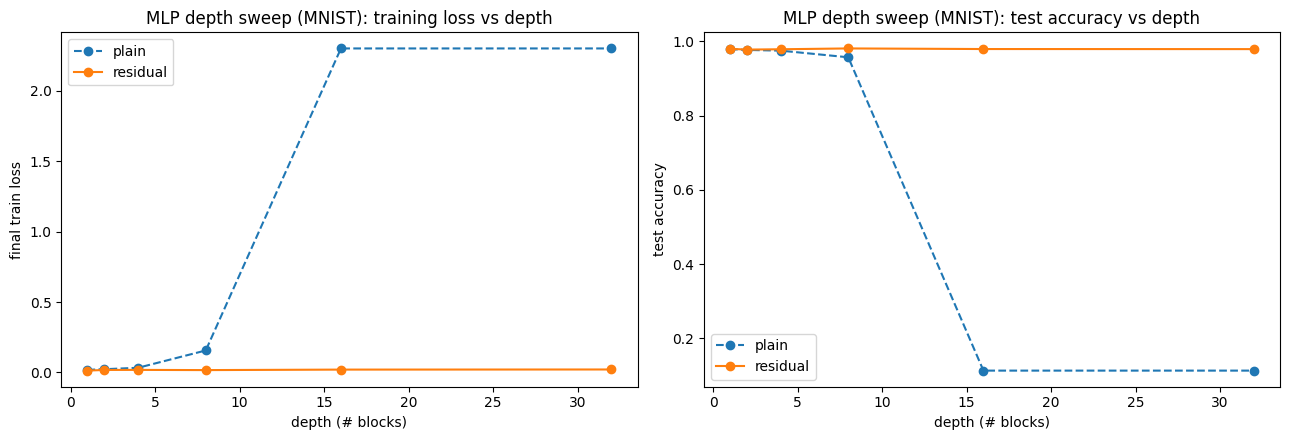

In [12]:
def plot_depth_sweep(sweep, depths, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for kind, style in [('plain', '--o'), ('residual', '-o')]:
        final_train_loss = [sweep[kind][d]['history']['train_loss'][-1] for d in depths]
        test_acc = [sweep[kind][d]['test_acc'] for d in depths]
        axes[0].plot(depths, final_train_loss, style, label=kind)
        axes[1].plot(depths, test_acc, style, label=kind)

    axes[0].set_xlabel('depth (# blocks)'); axes[0].set_ylabel('final train loss')
    axes[0].set_title(f'{title}: training loss vs depth'); axes[0].legend()
    axes[1].set_xlabel('depth (# blocks)'); axes[1].set_ylabel('test accuracy')
    axes[1].set_title(f'{title}: test accuracy vs depth'); axes[1].legend()
    fig.tight_layout()
    plt.show()

plot_depth_sweep(mlp_sweep, depths, 'MLP depth sweep (MNIST)')

L'idea centrale del paper di ResNet non è che una rete più profonda sia sempre peggiore, ma che le reti plain diventano più difficili da ottimizzare con la profondità, al punto che una rete plain più profonda può avere un errore di training più alto di una meno profonda. È un problema di degradazione, non di overfitting. Su MNIST con un MLP il loss di training della rete plain dovrebbe ricominciare a salire oltre una certa profondità, mentre quello della rete residual continua a scendere o si stabilizza in modo più graduale. Se un run non mostra questa degradazione a queste profondità, i sospetti principali sono blocchi da 128 unità troppo piccoli o solo 15 epoche di training, oppure il fatto che Adam è meno sensibile all'effetto rispetto a SGD.

L'analisi dei gradienti non usa le reti già allenate dallo sweep sopra, ma reti plain e residual appena inizializzate a ogni profondità, con un solo backward su un batch prima che parta il training. Con reti già allenate, entrambe convergono a un minimo locale dove i gradienti sono naturalmente piccoli ovunque, quindi il confronto misurerebbe soprattutto quanto ogni rete si è avvicinata alla convergenza e non l'effetto della skip connection. Con reti appena inizializzate invece si isola esattamente la variabile di interesse: come profondità e skip connection cambiano il flusso del gradiente nell'architettura.

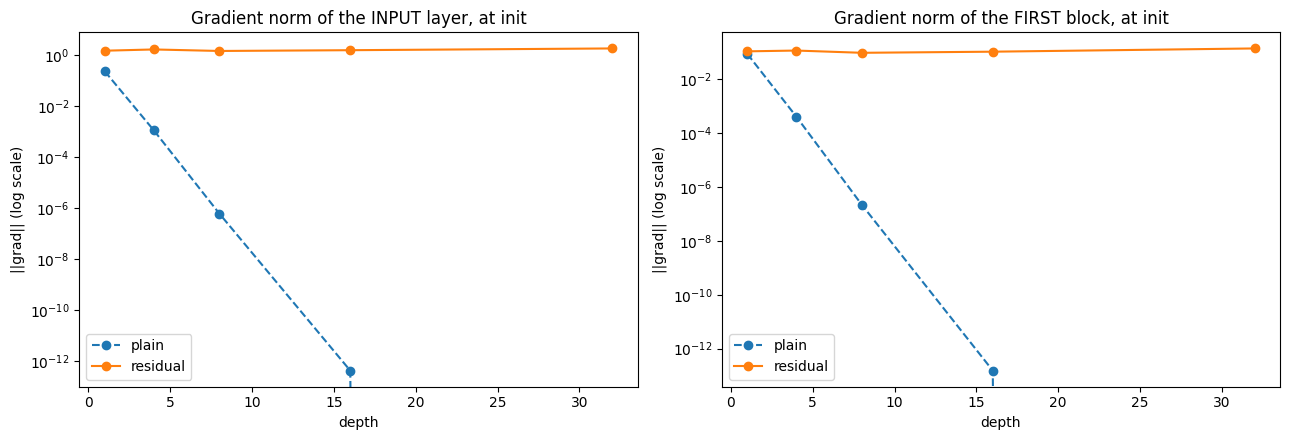

In [13]:
def gradient_norms_at_init(model, batch, criterion):
    model.train()
    xb, yb = batch
    xb, yb = xb.to(device), yb.to(device)
    model.zero_grad(set_to_none=True)
    loss = criterion(model(xb), yb)
    loss.backward()
    norms = {}
    for name, p in model.named_parameters():
        if p.grad is not None and 'weight' in name:
            norms[name] = p.grad.norm().item()
    return norms


sample_batch = next(iter(train_loader))
criterion = nn.CrossEntropyLoss()

grad_depths = [1, 4, 8, 16, 32]
input_layer_norms = {'plain': [], 'residual': []}
first_block_norms = {'plain': [], 'residual': []}

for depth in grad_depths:
    for kind, residual in [('plain', False), ('residual', True)]:
        torch.manual_seed(0)
        model = MLP(input_dim, width=128, depth=depth, num_classes=n_classes, residual=residual).to(device)
        norms = gradient_norms_at_init(model, sample_batch, criterion)
        input_layer_norms[kind].append(norms['input_layer.weight'])
        first_block_norms[kind].append(norms['blocks.0.fc1.weight'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for kind, style in [('plain', '--o'), ('residual', '-o')]:
    axes[0].semilogy(grad_depths, input_layer_norms[kind], style, label=kind)
    axes[1].semilogy(grad_depths, first_block_norms[kind], style, label=kind)
axes[0].set_xlabel('depth'); axes[0].set_ylabel('||grad|| (log scale)')
axes[0].set_title('Gradient norm of the INPUT layer, at init'); axes[0].legend()
axes[1].set_xlabel('depth'); axes[1].set_ylabel('||grad|| (log scale)')
axes[1].set_title('Gradient norm of the FIRST block, at init'); axes[1].legend()
fig.tight_layout()
plt.show()

Nella rete plain lo jacobiano di ogni blocco si moltiplica dentro la catena senza interruzioni, quindi con la profondità il gradiente che arriva ai primi layer è il prodotto di tanti termini del tipo ReLU'(x) per W. Con l'inizializzazione standard questi termini non conservano esattamente la norma, quindi il prodotto tende a rimpicciolirsi (o a volte esplodere) più o meno geometricamente con la profondità: il classico vanishing o exploding gradient. Nella rete residual ogni blocco calcola x più f(x), quindi il suo jacobiano è I più J_f. Il termine identità garantisce che esiste sempre almeno un percorso, quello fatto di sole identità, che porta il gradiente dalla loss fino al primo layer senza attenuazione, indipendentemente da quanto è profonda la pila di blocchi. Le skip connection non risolvono il vanishing gradient dentro f, lo aggirano. La norma del gradiente del layer di input dovrebbe quindi decadere molto più velocemente con la profondità nella rete plain rispetto alla residual.

### Exercise 1.3: Rinse and Repeat (but with a CNN)

Repeat the verification you did above, but with **Convolutional** Neural Networks. If you were careful about abstracting your model and training code, this should be a simple exercise. Show that **deeper** CNNs *without* residual connections do not always work better and **even deeper** ones *with* residual connections.

**Hint**: You probably should do this exercise using CIFAR-10, since MNIST is *very* easy (at least up to about 99% accuracy).

**Tip**: Feel free to reuse the ResNet building blocks defined in `torchvision.models.resnet` (e.g. [BasicBlock](https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py#L59) which handles the cascade of 3x3 convolutions, skip connections, and optional downsampling). This is an excellent exercise in code diving.

**Spoiler**: Depending on the optional exercises you plan to do below, you should think *very* carefully about the architectures of your CNNs here (so you can reuse them!).

Al posto di `torchvision.models.resnet.BasicBlock`, pensato per ImageNet con uno stem 7x7 e 4 stage fino a mappe 7x7 per immagini 224x224, uso il ResNet per CIFAR descritto nella sezione 4.2 di He et al. 2015: stem 3x3, 3 stage da 16, 32 e 64 canali con n blocchi residual ciascuno (downsampling con stride 2 all'inizio degli stage 2 e 3), global average pooling e classificatore lineare, per una profondità totale di 6n più 2. Riproduce l'esperimento usato dal paper per il suo argomento sulla degradazione (figura 6), invece di un'architettura pensata per una risoluzione diversa. Con n uguale a 3, 5, 7, 9 le profondità sono 20, 32, 44, 56 layer (il paper arriva fino a n uguale 18, cioè 110 layer, qui limitato per tempo di training). `PlainBlock` è identico al blocco residual, stesse convoluzioni, stesse batchnorm, stesso downsampling, ma senza la somma finale, così ogni differenza di comportamento si attribuisce solo alla skip connection.

In [14]:
class ResBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = None
        if stride != 1 or in_planes != planes:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        identity = x if self.downsample is None else self.downsample(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)


class PlainBlock(nn.Module):
    """Same computational graph as ResBlock, minus the skip connection."""
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        return out


class CifarResNet(nn.Module):
    def __init__(self, n_blocks_per_stage, num_classes=10, residual=True):
        super().__init__()
        block = ResBlock if residual else PlainBlock
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, 3, 1, 1, bias=False), nn.BatchNorm2d(16), nn.ReLU(inplace=True))

        def make_stage(in_planes, planes, n, stride):
            layers = [block(in_planes, planes, stride)]
            layers += [block(planes, planes, 1) for _ in range(n - 1)]
            return nn.Sequential(*layers)

        self.stage1 = make_stage(16, 16, n_blocks_per_stage, stride=1)
        self.stage2 = make_stage(16, 32, n_blocks_per_stage, stride=2)
        self.stage3 = make_stage(32, 64, n_blocks_per_stage, stride=2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, num_classes)
        self.depth = 6 * n_blocks_per_stage + 2

    def forward(self, x, return_features=False):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        feats = self.stage3(x)
        pooled = self.pool(feats).flatten(1)
        logits = self.fc(pooled)
        if return_features:
            return logits, feats
        return logits

In [15]:
train_loader_c, val_loader_c, test_loader_c, in_shape_c, n_classes_c = get_cifar10_loaders()

# CIFAR ResNet depths from the paper's own Section 4.2 experiment: 20, 32, 44, 56 layers.
n_values = [3, 5, 7, 9]
cnn_sweep = {'plain': {}, 'residual': {}}

for n in n_values:
    for kind, residual in [('plain', False), ('residual', True)]:
        torch.manual_seed(0)
        model = CifarResNet(n, num_classes=n_classes_c, residual=residual)
        run_name = f'{kind}_n{n}_depth{model.depth}'
        hist = fit(model, train_loader_c, val_loader_c, epochs=25, lr=1e-3,
                   log_dir='runs/ex1_3', run_name=run_name, patience=8)
        _, test_acc = evaluate(model, test_loader_c, nn.CrossEntropyLoss())
        cnn_sweep[kind][n] = {'history': hist, 'test_acc': test_acc, 'depth': model.depth,
                               'state_dict': {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}
        print(f'{run_name}: test_acc={test_acc:.4f}')

100%|██████████| 170M/170M [1:14:04<00:00, 38.4kB/s]


plain_n3_depth20:   0%|          | 0/25 [00:00<?, ?it/s]

plain_n3_depth20: test_acc=0.8214


residual_n3_depth20:   0%|          | 0/25 [00:00<?, ?it/s]

residual_n3_depth20: test_acc=0.8519


...

residual_n7_depth44: test_acc=0.8518


plain_n9_depth56:   0%|          | 0/25 [00:00<?, ?it/s]

plain_n9_depth56: test_acc=0.7376


residual_n9_depth56:   0%|          | 0/25 [00:00<?, ?it/s]

residual_n9_depth56: test_acc=0.8579


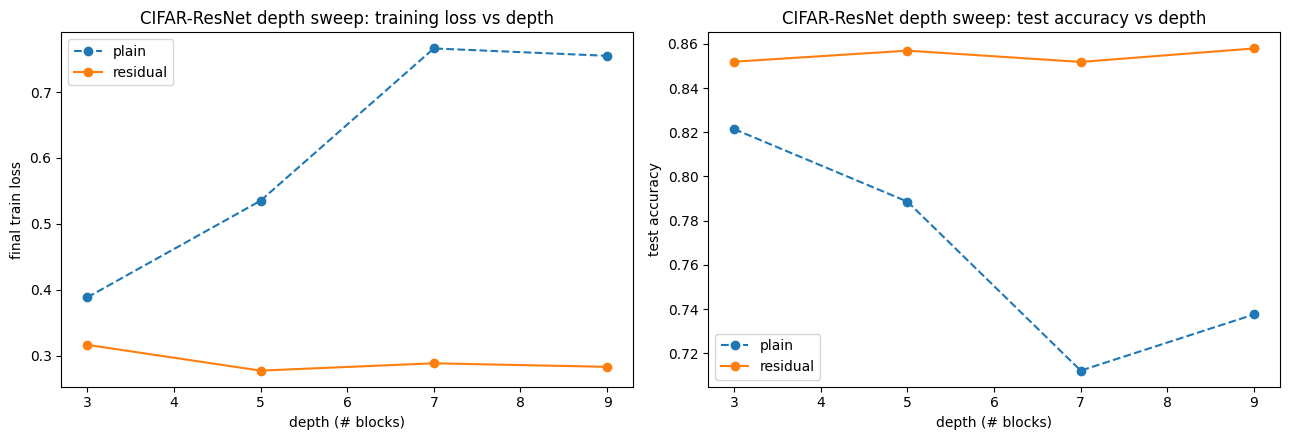

Depths (layers) corresponding to n = [3, 5, 7, 9] -> [20, 32, 44, 56]


In [16]:
depths_actual = [6 * n + 2 for n in n_values]
plot_depth_sweep({'plain': {n: cnn_sweep['plain'][n] for n in n_values},
                   'residual': {n: cnn_sweep['residual'][n] for n in n_values}},
                  n_values, 'CIFAR-ResNet depth sweep')
print('Depths (layers) corresponding to n =', n_values, '->', depths_actual)

Equivalente su CIFAR-10 della figura 6 del paper di ResNet. Con n, quindi la profondità, che aumenta, l'accuracy di training della rete plain dovrebbe stabilizzarsi e poi peggiorare, non per overfitting (in quel caso val e test si allontanerebbero dal train) ma perché la rete plain più profonda è più difficile da ottimizzare con lo stesso budget di epoche. La rete residual dovrebbe continuare a migliorare, o almeno non degradare, sullo stesso intervallo di profondità. n uguale 9 (56 layer) è la configurazione con più probabilità di mostrare un divario evidente rispetto a n uguale 3 (20 layer). Se un run non lo riproduce, i sospetti principali sono poche epoche o un learning rate tarato per la rete residual troppo alto per quella plain profonda.

-----
## Exercise 2: Choose at Least One

Below are **three** exercises that ask you to deepen your understanding of Deep Networks for visual recognition. You must choose **at least one** of the below for your final submission -- feel free to do **more**, but at least **ONE** you must submit. Each exercise is designed to require you to dig your hands **deep** into the guts of your models in order to do new and interesting things.

**Note**: These exercises are designed to use your small, custom CNNs and small datasets. This is to keep training times reasonable. If you have a decent GPU, feel free to use pretrained ResNets and larger datasets (e.g. the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset at 160px).

### Exercise 2.1: *Fine-tune* a pre-trained model
Train one of your residual CNN models from Exercise 1.3 on CIFAR-10. Then:
1. Use the pre-trained model as a **feature extractor** (i.e. to extract the feature activations of the layer input into the classifier) on CIFAR-100. Use a **classical** approach (e.g. Linear SVM, K-Nearest Neighbor, or Bayesian Generative Classifier) from scikit-learn to establish a **stable baseline** performance on CIFAR-100 using the features extracted using your CNN.
2. Fine-tune your CNN on the CIFAR-100 training set and compare with your stable baseline. Experiment with different strategies:
    - Unfreeze some of the earlier layers for fine-tuning.
    - Test different optimizers (Adam, SGD, etc.).

Each of these steps will require you to modify your model definition in some way. For 1, you will need to return the activations of the last fully-connected layer (or the global average pooling layer). For 2, you will need to replace the original, 10-class classifier with a new, randomly-initialized 100-class classifier.

Tra i tre esercizi al punto 2 ne serve solo uno, ed è stato scelto il 2.3 qui sotto. `CifarResNet.forward(..., return_features=True)` restituisce già le attivazioni prima del classificatore che servirebbero per il punto 1, e `model.fc = nn.Linear(64, 100)` basterebbe per una testa a 100 classi per il punto 2: l'architettura dell'esercizio 1.3 rende questa estensione diretta se servisse.

### Exercise 2.2: *Distill* the knowledge from a large model into a smaller one
In this exercise you will see if you can derive a *small* model that performs comparably to a larger one on CIFAR-10. To do this, you will use [Knowledge Distillation](https://arxiv.org/abs/1503.02531):

> Geoffrey Hinton, Oriol Vinyals, and Jeff Dean. Distilling the Knowledge in a Neural Network, NeurIPS 2015.

To do this:
1. Train one of your best-performing CNNs on CIFAR-10 from Exercise 1.3 above. This will be your **teacher** model.
2. Define a *smaller* variant with about half the number of parameters (change the width and/or depth of the network). Train it on CIFAR-10 and verify that it performs *worse* than your **teacher**. This small network will be your **student** model.
3. Train the **student** using a combination of **hard labels** from the CIFAR-10 training set (cross entropy loss) and **soft labels** from predictions of the **teacher** (Kulback-Leibler loss between teacher and student).

Try to optimize training parameters in order to maximize the performance of the student. It should at least outperform the student trained only on hard labels in Setp 2.

**Tip**: You can save the predictions of the trained teacher network on the training set and adapt your dataloader to provide them together with hard labels. This will **greatly** speed up training compared to performing a forward pass through the teacher for each batch of training.

Esercizio non implementato per lo stesso motivo. `cnn_sweep['residual'][9]` dell'esercizio 1.3 sarebbe il teacher naturale, e `CifarResNet(1, residual=True)` (n uguale 1, profondità 8) lo student naturale, con circa un quinto dei parametri del teacher. Entrambi già prodotti dalla stessa classe `CifarResNet`, quindi servirebbero solo la loss di distillazione e il training loop, non una nuova architettura.

### Exercise 2.3: *Explain* the predictions of a CNN

Use the CNN model you trained in Exercise 1.3 and implement [*Class Activation Maps*](http://cnnlocalization.csail.mit.edu/#:~:text=A%20class%20activation%20map%20for,decision%20made%20by%20the%20CNN.):

> B. Zhou, A. Khosla, A. Lapedriza, A. Oliva, and A. Torralba. Learning Deep Features for Discriminative Localization. CVPR'16 (arXiv:1512.04150, 2015).

Use your CNN implementation to demonstrate how your trained CNN *attends* to specific image features to recognize *specific* classes. Try your implementation out using a pre-trained ResNet-18 model and some images from the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset -- I suggest you start with the low resolution version of images at 160px.

Il `CifarResNet` dell'esercizio 1.3 finisce già nell'architettura richiesta da CAM: global average pooling seguito da un solo layer lineare, senza bisogno di aggiungere o riallenare una testa. Implementazione del CAM classico di Zhou et al. 2016, non Grad-CAM: con il GAP subito prima del classificatore, la mappa di attivazione è esattamente una somma pesata delle ultime feature map convoluzionali, con i pesi dati dalla riga corrispondente del layer `fc` finale. Non servono gradienti.

In [17]:
class CAM:
    """Classic Class Activation Mapping (Zhou et al., CVPR 2016) for any model that ends
    in global-average-pool -> single Linear classifier acting directly on the pooled
    features (e.g. our CifarResNet, or a torchvision resnet18/34/50)."""
    def __init__(self, model, feature_layer_name, fc_layer_name):
        self.model = model.eval()
        self.features = None
        fc = dict(model.named_modules())[fc_layer_name]
        self.fc_weight = fc.weight.detach()  # (num_classes, num_feature_channels)

        layer = dict(model.named_modules())[feature_layer_name]
        layer.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self.features = out.detach()

    @torch.no_grad()
    def __call__(self, x, class_idx=None):
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1)
        feats = self.features  # (B, C, H, W)
        weights = self.fc_weight[class_idx]  # (B, C)
        cam = torch.einsum('bchw,bc->bhw', feats, weights)
        cam = F.relu(cam)
        cam = cam - cam.amin(dim=(1, 2), keepdim=True)
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cam, logits, class_idx


def show_cam(image_chw, cam, ax=None, alpha=0.45, cmap='jet'):
    """image_chw: de-normalised float tensor in [0, 1], shape (3, H, W)."""
    img = image_chw.permute(1, 2, 0).cpu().numpy()
    cam_up = F.interpolate(cam[None, None], size=img.shape[:2], mode='bilinear',
                            align_corners=False)[0, 0].cpu().numpy()
    ax = ax or plt.gca()
    ax.imshow(img)
    ax.imshow(cam_up, cmap=cmap, alpha=alpha)
    ax.axis('off')

#### CAM sul ResNet allenato su CIFAR-10

Modello residual più profondo dell'esercizio 1.3 (n uguale 9, profondità 56), CAM su qualche immagine del test set.

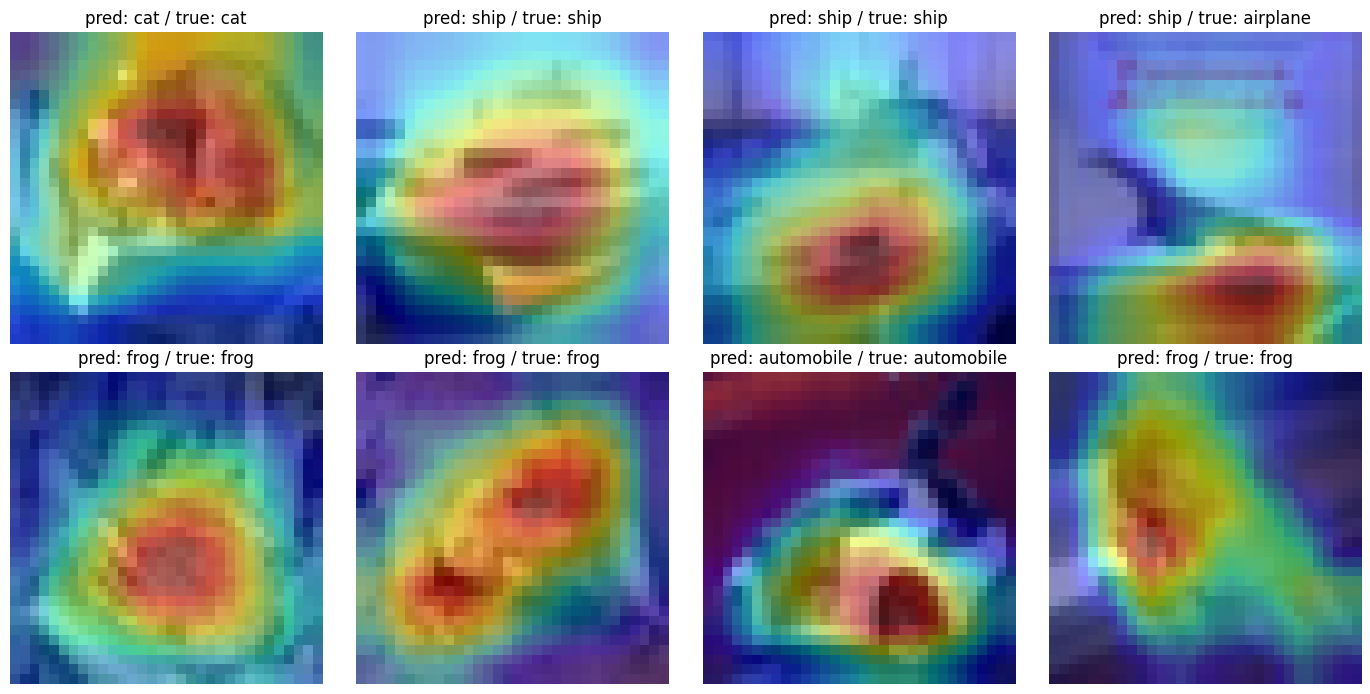

In [18]:
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']
cifar_mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
cifar_std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

def denormalize(x, mean=cifar_mean, std=cifar_std):
    return (x.cpu() * std + mean).clamp(0, 1)

deepest_resnet = CifarResNet(9, num_classes=10, residual=True).to(device)
deepest_resnet.load_state_dict(cnn_sweep['residual'][9]['state_dict'])  # trained in Exercise 1.3
cam_extractor = CAM(deepest_resnet, feature_layer_name='stage3', fc_layer_name='fc')

images, labels = next(iter(test_loader_c))
images = images[:8].to(device)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    cam, logits, pred = cam_extractor(images[i:i+1])
    show_cam(denormalize(images[i]), cam[0], ax=ax)
    ax.set_title(f'pred: {cifar_classes[pred.item()]} / true: {cifar_classes[labels[i].item()]}')
fig.tight_layout()
plt.show()

#### CAM su ResNet-18 pre allenato su ImageNet, immagini in stile Imagenette

Funziona con qualsiasi immagine locale: `IMAGE_PATH` deve puntare a una foto con un oggetto ben centrato di una delle 1000 classi di ImageNet (per esempio un'immagine Imagenette a 160px). Riproduce la figura 3 del paper del CAM. Senza percorso impostato la cella stampa un messaggio e viene saltata, il resto del notebook continua a funzionare.

In [19]:
import torchvision.models as tvm
from PIL import Image

IMAGE_PATH = ''  # <-- set this to a local image path (e.g. an Imagenette 160px image)

if IMAGE_PATH and os.path.exists(IMAGE_PATH):
    imagenet_resnet = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1).to(device).eval()
    imagenet_classes = tvm.ResNet18_Weights.IMAGENET1K_V1.meta['categories']

    imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    preprocess = T.Compose([
        T.Resize(256), T.CenterCrop(224), T.ToTensor(),
        T.Normalize(imagenet_mean.flatten().tolist(), imagenet_std.flatten().tolist()),
    ])

    img = Image.open(IMAGE_PATH).convert('RGB')
    x = preprocess(img).unsqueeze(0).to(device)

    imagenet_cam = CAM(imagenet_resnet, feature_layer_name='layer4', fc_layer_name='fc')
    cam, logits, pred = imagenet_cam(x)
    top5 = logits[0].topk(5).indices.tolist()

    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    ax[0].imshow(img); ax[0].axis('off'); ax[0].set_title('input')
    show_cam(denormalize(x[0].cpu(), imagenet_mean, imagenet_std), cam[0], ax=ax[1])
    ax[1].set_title(f'CAM for: {imagenet_classes[pred.item()]}')
    fig.tight_layout()
    plt.show()

    print('Top-5 predictions:')
    for idx in top5:
        print(f'  {imagenet_classes[idx]:<25s} logit={logits[0, idx].item():.2f}')
else:
    print('No image path provided. Skipping the ImageNet CAM example.')

No image path provided. Skipping the ImageNet CAM example.


La mappa CAM è una combinazione lineare dei canali dell'ultimo layer convoluzionale, pesata dalla riga di `fc` della classe scelta. Mostra dove si trovano spazialmente le feature a cui risponde il vettore di pesi di quella classe, non letteralmente dove guarda la rete in senso causale. Due limiti da tenere presenti. Se due classi condividono gran parte delle evidenze, per esempio husky e malamute, i loro CAM si assomigliano quasi identici anche se la vera ragione di una predizione rispetto all'altra sta in pochi canali specifici. Un'architettura che non finisce con global average pooling subito prima del classificatore, per esempio con altri layer fully connected o pooling non globale, non si presta a questa ricetta e ha bisogno di Grad-CAM, che sostituisce i pesi fissi di `fc` con il gradiente dello score della classe rispetto a ogni canale, mediato spazialmente. Grad-CAM è una generalizzazione che in questo caso si riduce esattamente al CAM classico.

## Riassunto

| Esercizio | Cosa è stato costruito | Astrazione riusata |
|---|---|---|
| 1.1 | MLP di base su MNIST | `MLP(residual=False)`, `fit()` |
| 1.2 | MLP residual, sweep di profondità 1,2,4,8,16,32, analisi dei gradienti all'inizializzazione | stessa classe `MLP`, `residual=True` |
| 1.3 | ResNet in stile CIFAR, plain contro residual, sweep di profondità 20,32,44,56 layer | `CifarResNet(residual=...)`, stessa `fit()` |
| 2.3 (scelto) | Class Activation Maps sul ResNet allenato su CIFAR e su un ResNet-18 pre allenato su ImageNet | riusa `stage3` o `layer4` più `fc` dei modelli allenati sopra |

Un'unica astrazione per il modello e un unico training loop, usati in tutti gli esercizi: ogni confronto plain contro residual (1.2, 1.3) cambia solo il flag booleano `residual`, tutto il resto resta identico tra le due condizioni.